<a href="https://colab.research.google.com/github/Pranjal11095/BEE/blob/main/23114084_BEE_coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Question 1**
Fragment length frequency (1 mark) + rescaling (2 marks)
You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Narmalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

query.bed.gz

Rescaling
Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

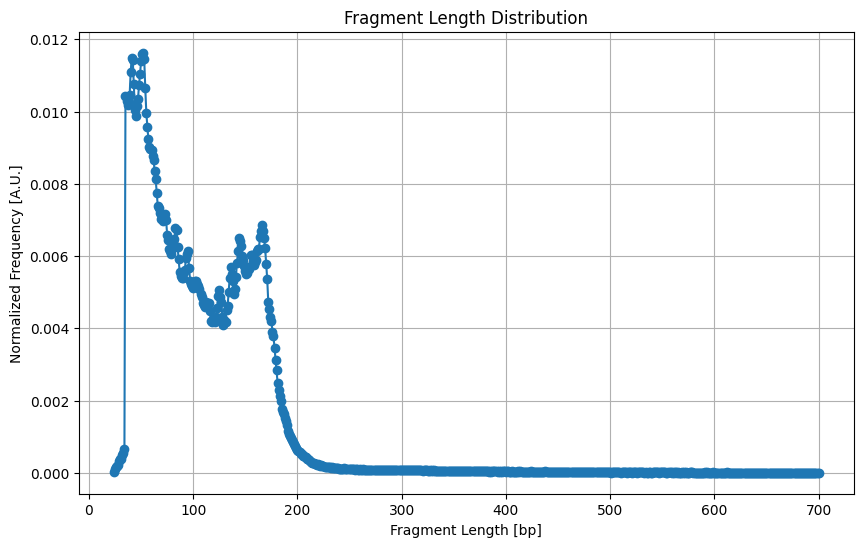

In [21]:
import gzip
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Read the .bed.gz file and calculate fragment lengths
fragment_lengths = []

# Note: The file path is '/content/query.bed.gz' after you upload
file_path = '/content/drive/MyDrive/query.bed.gz'
with gzip.open(file_path, 'rt') as f:
    for line in f:
        if line.strip() == '':
            continue  # Skip empty lines
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            start = int(parts[1])
            end = int(parts[2])
            fragment_length = end - start
            if fragment_length > 0:  # Only positive fragment lengths
                fragment_lengths.append(fragment_length)

# Step 2: Count fragment lengths
length_counter = Counter(fragment_lengths)

# Step 3: Normalize the counts
total_fragments = sum(length_counter.values())
normalized_freq = {length: count / total_fragments for length, count in length_counter.items()}

# Step 4: Plot
x = sorted(normalized_freq.keys())
y = [normalized_freq[length] for length in x]

plt.figure(figsize=(10,6))
plt.plot(x, y, marker='o', linestyle='-')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.grid(True)
plt.show()


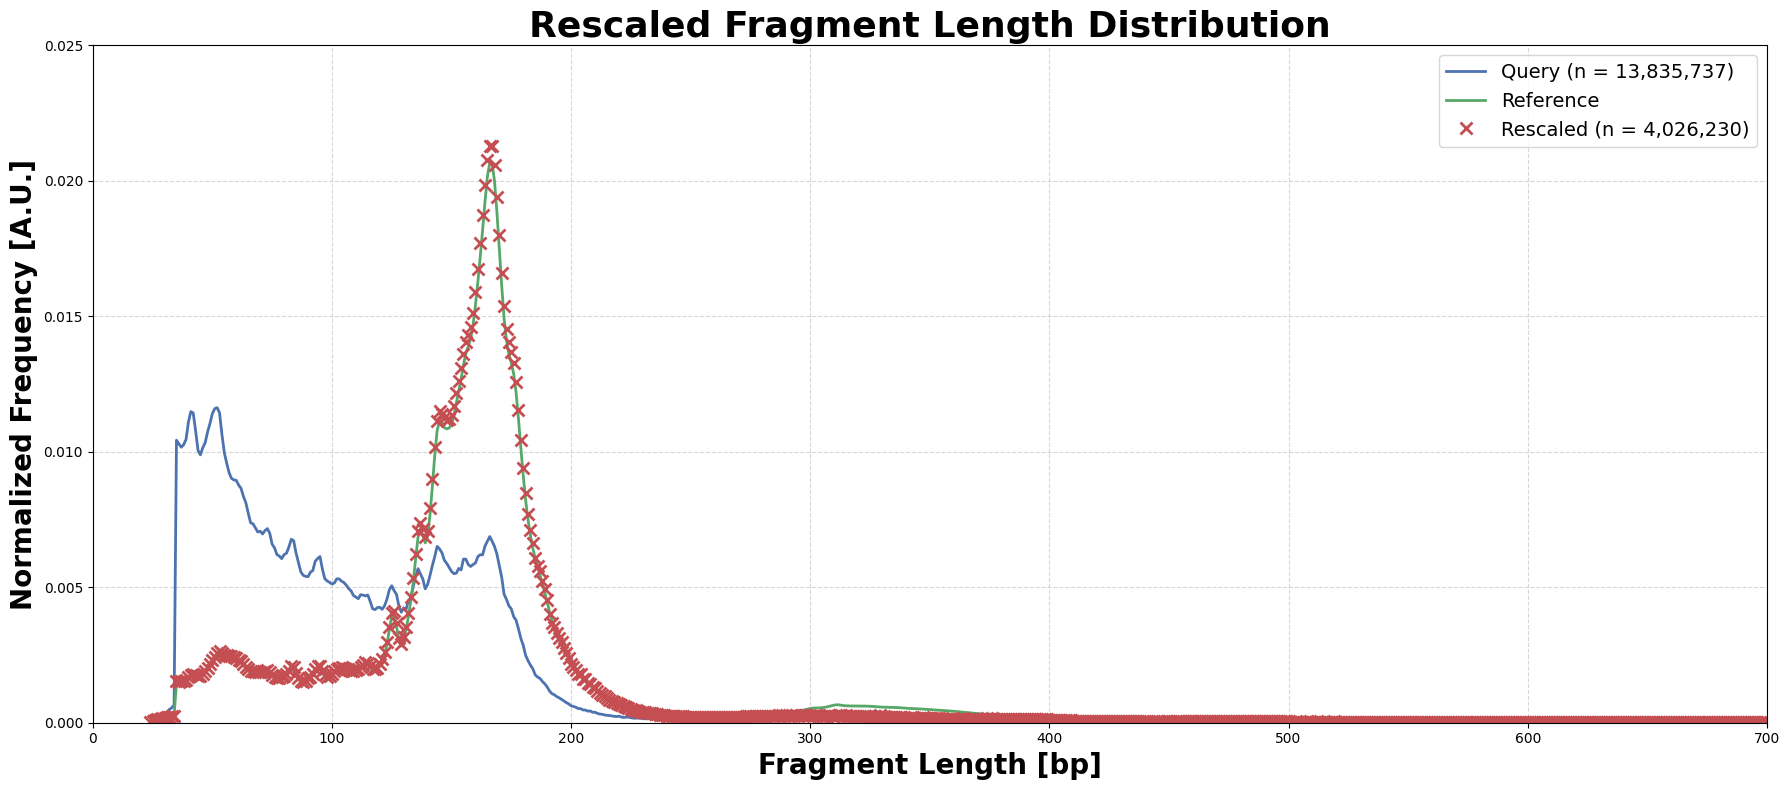

In [22]:
import gzip
import matplotlib.pyplot as plt
from collections import Counter
import random

# --- Load reference.hist ---
def load_reference_hist(path):
    with open(path) as f:
        ref = {int(l): float(f) for l, f in (line.strip().split('\t') for line in f if line.strip())}
    total = sum(ref.values())
    return {k: v / total for k, v in ref.items()}

ref_freq_dict = load_reference_hist('/content/drive/MyDrive/reference.hist')

# --- Load fragment lengths from query.bed.gz ---
def load_fragment_lengths(bed_path):
    with gzip.open(bed_path, 'rt') as f:
        return [int(p[2]) - int(p[1]) for p in (line.strip().split('\t') for line in f if line.strip()) if int(p[2]) > int(p[1])]

fragment_lengths = load_fragment_lengths('/content/drive/MyDrive/query.bed.gz')
length_freq = Counter(fragment_lengths)
total_fragments = sum(length_freq.values())

# --- Normalize query frequency ---
normalized_query_freq = {l: c / total_fragments for l, c in length_freq.items()}
sorted_lengths = sorted(normalized_query_freq.keys())
sorted_freqs = [normalized_query_freq[l] for l in sorted_lengths]

# --- Subsample (rescale) query to match reference ---
frag_by_length = {}
for l in fragment_lengths:
    frag_by_length.setdefault(l, []).append(l)

target_total = int(total_fragments * 0.3)
rescaled_fragments = []

for l, ref_freq in ref_freq_dict.items():
    if l in frag_by_length:
        desired_count = int(ref_freq * target_total)
        pool = frag_by_length[l]
        sampled = random.sample(pool, min(len(pool), desired_count))
        rescaled_fragments.extend(sampled)

# --- Compute rescaled frequency ---
rescaled_counts = Counter(rescaled_fragments)
total_rescaled = sum(rescaled_counts.values())
rescaled_freq = {l: c / total_rescaled for l, c in rescaled_counts.items()}

# --- Prepare reference data for plotting ---
ref_lengths = sorted(ref_freq_dict.keys())
ref_freqs = [ref_freq_dict[l] for l in ref_lengths]

# --- Plot with improved styling ---
plt.figure(figsize=(18, 8))

# Custom font settings
font_title = {'fontsize': 26, 'weight': 'bold'}
font_labels = {'fontsize': 20, 'weight': 'semibold'}
font_legend = {'fontsize': 14}

plt.plot(sorted_lengths, sorted_freqs, label=f'Query (n = {total_fragments:,})', color='#4C72B0', linewidth=2)
plt.plot(ref_lengths, ref_freqs, label='Reference', color='#55A868', linewidth=2)
plt.plot(sorted(rescaled_freq.keys()),
         [rescaled_freq[l] for l in sorted(rescaled_freq.keys())],
         'x', label=f'Rescaled (n = {total_rescaled:,})',
         color='#C44E52', markersize=8, markeredgewidth=2)

plt.xlabel("Fragment Length [bp]", **font_labels)
plt.ylabel("Normalized Frequency [A.U.]", **font_labels)
plt.title("Rescaled Fragment Length Distribution", **font_title)
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(**font_legend)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("./rescaled_prediction.png")
plt.show()


# **Question2**
Building Markov transition matrix
You have learned important differences between simple dinucleotide frequency model and Markov models. Your goal is to build one from the input sequence. In the Jupyter notebook, you should print the transition matrix.

In [23]:
from collections import defaultdict
import pandas as pd

def build_markov_transition(sequence):
    nucleotides = ['A', 'C', 'G', 'T']
    counts = defaultdict(lambda: defaultdict(int))

    # Count transitions between consecutive nucleotides
    for i in range(len(sequence)-1):
        current = sequence[i].upper()
        next_nt = sequence[i+1].upper()
        if current in nucleotides and next_nt in nucleotides:
            counts[current][next_nt] += 1

    # Create normalized probability matrix
    df = pd.DataFrame(index=nucleotides, columns=nucleotides, data=0.0)
    for nt in nucleotides:
        total = sum(counts[nt].values())
        if total > 0:
            for target in nucleotides:
                df.loc[nt, target] = counts[nt][target] / total
        else:  # Handle nucleotides with no observed transitions
            df.loc[nt] = 1/len(nucleotides)

    return df

# Example usage
dna = "ACGTACGTGACGTTACG"
matrix = build_markov_transition(dna)
print("Markov Transition Matrix:")
print(matrix.round(2))


Markov Transition Matrix:
      A    C     G     T
A  0.00  1.0  0.00  0.00
C  0.00  0.0  1.00  0.00
G  0.25  0.0  0.00  0.75
T  0.50  0.0  0.25  0.25


# **Question3**
Multi-line sequence fasta to single-line fasta file
Fasta file format is shown below. Many times, it is annoying to find sequences of interest because of fix-width format, i.e., if 60 character fix-width file is there then only except the header (starting with >) of the sequence each line will have 60 characters. So, if a sequence is of width 600, then it would be written in 10 lines. Your goal is convert this format to a format with header in a single line followed by its sequence in a single line

In [25]:
input_file = '/content/drive/MyDrive/multiline_input.fasta'  # Change to your file path

with open(input_file, 'r') as infile:
    sequence = ''
    for line in infile:
        line = line.strip()
        if line.startswith('>'):  # Header line
            if sequence:  # Print previous sequence
                print(sequence)
                sequence = ''
            print(line)  # Print the header line
        else:  # Sequence line
            sequence += line
    if sequence:  # Print the last sequence
        print(sequence)

print("FASTA file processed and output shown on screen.")


>1
TCCAATTGAGCTATACCGTCAGAAGTAGATGAGATCTAACGGCGCGCCCGGTTGTCGCAGCCACGCTAGGCACAGTCAAAGCAGTGACCCAGCCCTTCAGACGTTACTGTGAAAATCTGTCCACCGAGAACGCTTTCAAAATATATTAGCGGTTTAAGCTAGGCAAGTCACGGCATGTCCTTACAAAAGCCTACGAGCCGGGCCACATTATGTCGCCCATAAGATGCCAATACAATCTCAAGTAGGATAAGCATGTCTTACCACTAGCGTTCTGTGTTTGTGGGGTTACGCGTTGTGTTACCAACGGTCCCCTATAGCTCAGCAGTAATAAGTTTTATTGTGCTCAAGGCC
>2
GATAGCGACGACGCTAGTTCCTAGGGACCCGGGGGGGATCAGTGGTGACGGTATGCTCTTGCTGGTGCGACCCGTAACGAAGTCACATGGGTAGTGGCGGCACAGGATATCGTAGTGACAGGAACCTGATATTCCGTTGCAGAACACACGCGACAATCTACAAGTTATTTTCGGCTGAGTTACTTACTCACAAGATCCACATGGAAATTTAATATACGACGCTGAGGAGGGTTGCACAACGGCTCTCTTTCCTAAGAACAGAATTGCCTAAGAATTCAGAGCTCAAAGGCTCCATTTCTTGAGGTATGGTCGTCGGTATATTAACGGTGCTA
>3
GCCTATCTCACATGATAACCAGGTCTAGTTATGCTATTCATATACCTACTGTGTCCACTTTCTGTACTCCACGCGCGTACATAAGTACTGGAGTTAAATACAATGAAACGATGCAAGATGGGCTAAAGTTCAAGGAGGAGCTCTGCCATATCATTCTCTACAGCAAGACTGGGGCTCTGGGAATGGAGATAAAAAGGAGTTACATGCACGTAAAGTCGCCATCCATGCTACTTTGTTTGGCGCGGGGAACGCCCCGCCCTACTATTCATATGTCTACAC
>4
GTAACCCTATAGTCAGGAGGTCA

# **Question 4**
Write the Viterbi algorithm to implment Nature Primer.

Here are some suggestions:

a. You can begin by first defining all the parameters, such as states, transition matrix, and emmision matrix etc.

b. You can write a function to exactly calculate the values mentioned in the primer, for example, you can define a function get_log_prob_of_a_given_path ("EEEEEEEEEEEEEEEEEE5IIIIIII", "CTTCATGTGAAAGCAGACGTAAGTCA"). This should output -41.22.

By doing the above two, you earn 1 mark.

Now, you have to implement this in real to get max likely path that would emmit the observed sequence. You MUST note that maximum likely path will just be Es, but that is okay. Implementation is the key.

In [26]:
import numpy as np
import math

# Define HMM components
states = ['E', '5', 'I']
nucleotides = ['A', 'C', 'G', 'T']

initial_probabilities = {'E': 1.0, '5': 0.0, 'I': 0.0}

transition_probabilities = {
    'Start': {'E': 1.0, '5': 0.0, 'I': 0.0, 'End': 0.0},
    'E':     {'E': 0.9, '5': 0.1, 'I': 0.0, 'End': 0.0},
    '5':     {'E': 0.0, '5': 0.0, 'I': 1.0, 'End': 0.0},
    'I':     {'E': 0.0, '5': 0.0, 'I': 0.9, 'End': 0.1}
}

emission_probs = {
    'E': {'A': 0.25, 'C': 0.25, 'G': 0.25, 'T': 0.25},
    '5': {'A': 0.05, 'C': 0.00, 'G': 0.95, 'T': 0.00},
    'I': {'A': 0.40, 'C': 0.10, 'G': 0.10, 'T': 0.40}
}

def log(x):
    return -math.inf if x == 0 else math.log(x)

def get_log_prob_of_a_given_path(state_path, observed_sequence):
    if len(state_path) != len(observed_sequence):
        raise ValueError("State path and observed sequence must be the same length")

    log_prob = 0.0
    prev_state = 'Start'

    for state, obs in zip(state_path, observed_sequence):
        if obs not in nucleotides:
            raise ValueError(f"Invalid nucleotide '{obs}' in observed sequence")

        trans_prob = transition_probabilities[prev_state][state]
        emit_prob = emission_probs[state][obs]

        log_prob += log(trans_prob) + log(emit_prob)
        prev_state = state

    if prev_state == 'I':
        log_prob += log(transition_probabilities['I']['End'])

    return log_prob

# Example usage
state_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
observed_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"
log_probability = get_log_prob_of_a_given_path(state_path, observed_sequence)

print("Log probability of the given path:", log_probability)


Log probability of the given path: -41.21967768602254


In [27]:
import numpy as np
import math

def log(x):
    return -math.inf if x == 0 else math.log(x)

def viterbiAlgo(observed_sequence):
    num_states = len(states)
    num_observations = len(observed_sequence)

    viterbi_matrix = np.full((num_states, num_observations), -np.inf)
    backpointers = np.zeros((num_states, num_observations), dtype=int)

    state_to_index = {s: i for i, s in enumerate(states)}

    # Initialization
    for i, state in enumerate(states):
        viterbi_matrix[i, 0] = log(initial_probabilities[state]) + \
                               log(emission_probs[state][observed_sequence[0]])

    # Recursion
    for t in range(1, num_observations):
        for curr_index, curr_state in enumerate(states):
            max_log_prob = -math.inf
            best_prev_idx = 0
            for prev_index, prev_state in enumerate(states):
                trans_log_prob = log(transition_probabilities[prev_state][curr_state])
                total_log_prob = viterbi_matrix[prev_index, t-1] + trans_log_prob
                if total_log_prob > max_log_prob:
                    max_log_prob = total_log_prob
                    best_prev_idx = prev_index
            viterbi_matrix[curr_index, t] = max_log_prob + \
                                            log(emission_probs[curr_state][observed_sequence[t]])
            backpointers[curr_index, t] = best_prev_idx

    # Termination and backtracking
    best_last_state_index = np.argmax(viterbi_matrix[:, -1])
    best_path = [states[best_last_state_index]]

    for t in range(num_observations - 1, 0, -1):
        best_last_state_index = backpointers[best_last_state_index, t]
        best_path.insert(0, states[best_last_state_index])

    best_log_prob = np.max(viterbi_matrix[:, -1])
    return best_path, best_log_prob

# Example usage
observed_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"
best_path, log_prob = viterbiAlgo(observed_sequence)

print(f"Most probable path is: {''.join(best_path)}")
print(f"Log probability of the path: {log_prob}")


Most probable path is: EEEEEEEEEEEEEEEEEEEEEEEEEE
Log probability of the path: -38.677666280562796


# **Question 5**
You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.


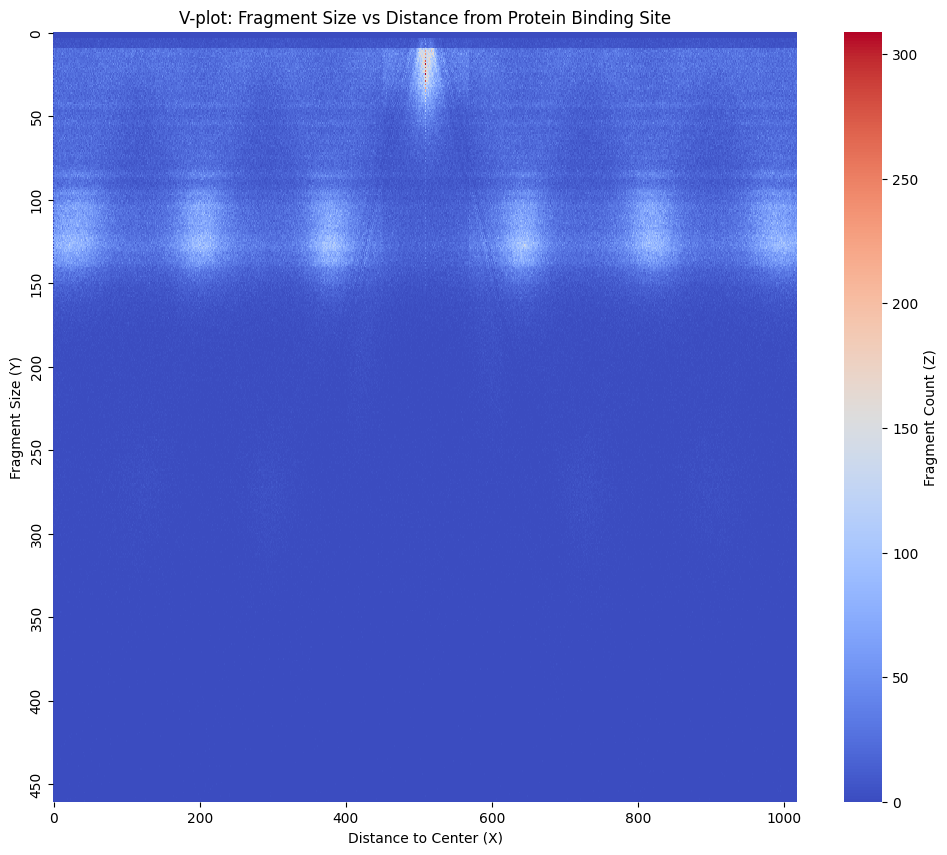

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gzip
from collections import Counter

# Step 1: Load the data
data = []
file_path = '/content/drive/MyDrive/mapped.bed.gz'

with gzip.open(file_path, 'rt') as f:  # 'rt' means read text mode
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 11:
            continue

        c1 = (int(parts[2]) + int(parts[3])) / 2
        c2 = (int(parts[8]) + int(parts[9])) / 2

        x = int(c2 - c1)
        y = int(parts[9]) - int(parts[8])

        data.append((x, y))

# Step 2: Count how many times each (X, Y) occurs
counter = Counter(data)

# Step 3: Prepare 2D grid
# Define X and Y ranges
x_vals = [x for x, y in counter.keys()]
y_vals = [y for x, y in counter.keys()]

x_min, x_max = min(x_vals), max(x_vals)
y_min, y_max = min(y_vals), max(y_vals)

# Build 2D array
heatmap = np.zeros((y_max - y_min + 1, x_max - x_min + 1))

for (x, y), count in counter.items():
    heatmap[y - y_min, x - x_min] = count

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap, cmap="coolwarm",
            xticklabels=200, yticklabels=50,
            cbar_kws={'label': 'Fragment Count (Z)'})
plt.title("V-plot: Fragment Size vs Distance from Protein Binding Site")
plt.xlabel("Distance to Center (X)")
plt.ylabel("Fragment Size (Y)")
plt.show()


# **Question 6**
Principle Component Analysis (2 marks)
Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File paths in Google Drive
class_labels_path = '/content/drive/MyDrive/class.tsv'
columns_path = '/content/drive/MyDrive/columns.tsv.gz'
filtered_data_path = '/content/drive/MyDrive/filtered.tsv.gz'

# Load class labels (1 = ER+, 0 = ER-)
labels = pd.read_csv(class_labels_path, sep='\t', header=None)[0].values

# Load gene name mapping
with gzip.open(columns_path, 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]

gene_mapping = pd.read_csv(StringIO(''.join(lines)), sep='\t')

# Load gene expression data
with gzip.open(filtered_data_path, 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t', index_col=0)

expression_data.columns = expression_data.columns.astype(str).str.strip()

# Extract gene IDs
xbp1_id = '4404'  # Given in the problem
gata3_id = str(gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0])

# Extract expression values
xbp1_expression = expression_data[xbp1_id].values
gata3_expression = expression_data[gata3_id].values

# Set up colors based on class labels
colors = ['black' if label == 0 else 'red' for label in labels]

# You can now add plotting or analysis as needed using xbp1_expression and gata3_expression


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


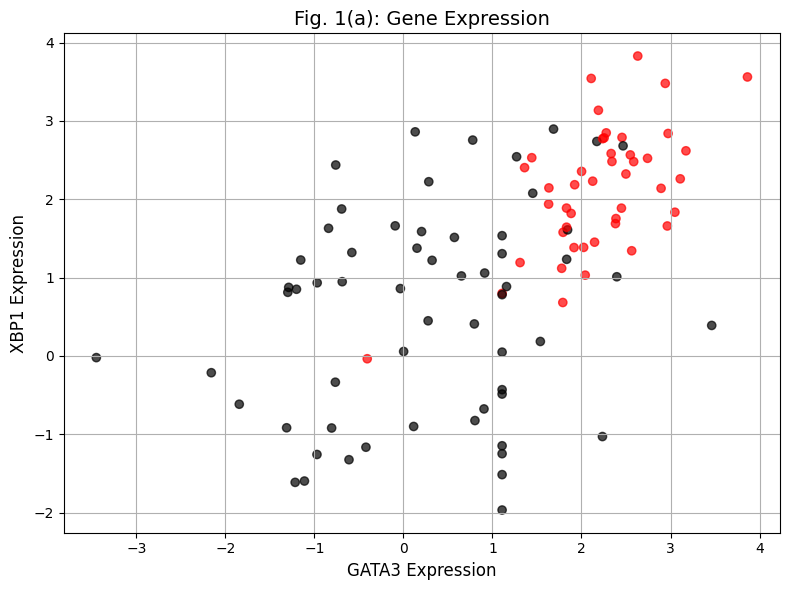

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# PCA function
def perform_pca(X):
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvectors, eigenvalues, x_centered

# Apply PCA to XBP1 and GATA3 expression
X = np.column_stack((gata3_expression, xbp1_expression))
eigvecs, eigvals, X_centered = perform_pca(X)

# Plot: Figure 1(a) - Scatter plot of GATA3 vs XBP1
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('Fig. 1(a): Gene Expression', fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.show()


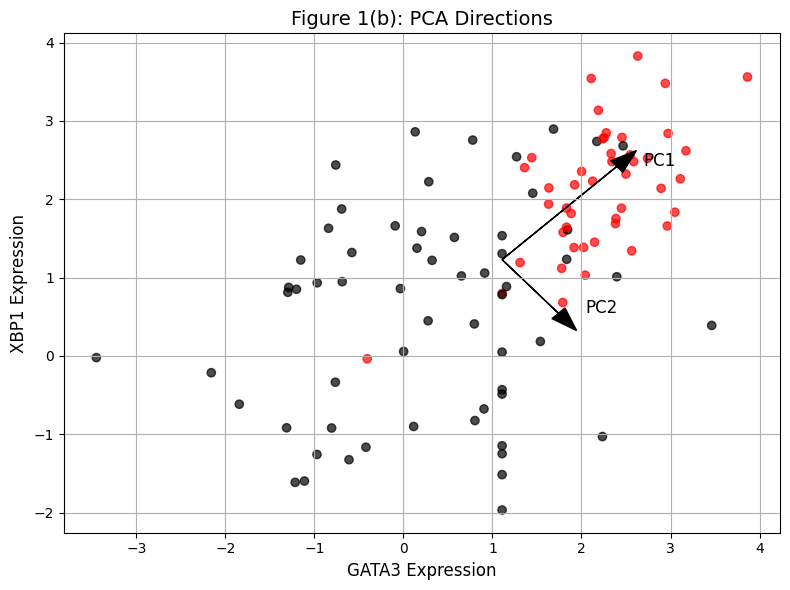

In [31]:
# Prepare input matrix
X = np.column_stack((gata3_expression, xbp1_expression))

# Perform PCA
eigenvectors, eigenvalues, X_centered = perform_pca(X)
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# Flip PC1 direction if needed (ER+ should be higher on PC1)
proj_pc1 = np.dot(X_centered, pc1)
proj_pc2 = np.dot(X_centered, pc2)
if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
    pc1 = -pc1
    proj_pc1 = -proj_pc1

# Compute mean of original features for arrow base
mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)

# Scale components for better visualization
scale1 = np.sqrt(eigenvalues[0])
scale2 = np.sqrt(eigenvalues[1])

# Plot Figure 1(b)
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(mean_gata3 + pc1[0]*scale1 + 0.3, mean_xbp1 + pc1[1]*scale1, 'PC1', fontsize=12)
plt.text(mean_gata3 + pc2[0]*scale2 + 0.3, mean_xbp1 + pc2[1]*scale2, 'PC2', fontsize=12)

plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('Figure 1(b): PCA Directions', fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.show()


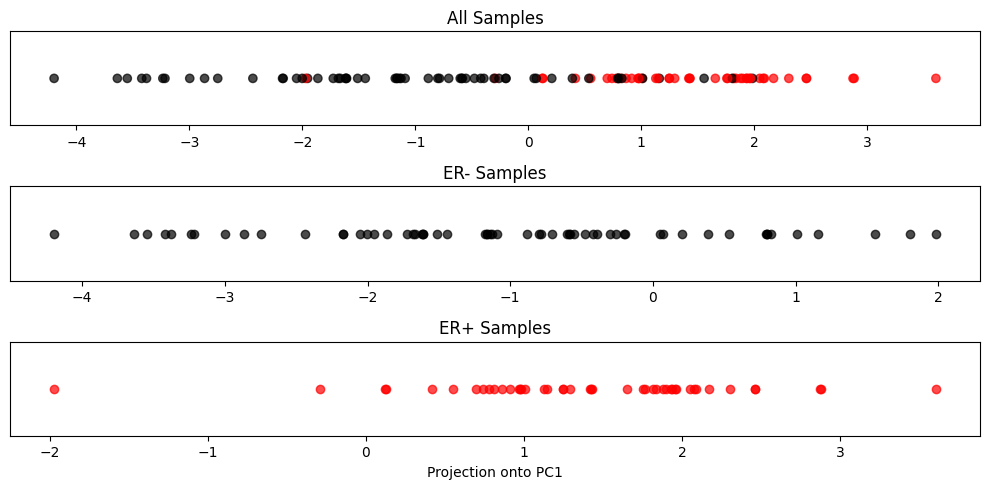

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [32]:
def perform_pca(X):
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvectors, eigenvalues, x_centered

# Combine GATA3 and XBP1 expression
x = np.column_stack((gata3_expression, xbp1_expression))

# Run PCA
eigenvectors, eigenvalues, x_centered = perform_pca(x)

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

projection_pc1 = np.dot(x_centered, pc1)
projection_pc2 = np.dot(x_centered, pc2)

# Flip sign of PC1 if needed
if np.mean(projection_pc1[labels == 1]) < np.mean(projection_pc1[labels == 0]):
    pc1 = -pc1
    projection_pc1 = -projection_pc1

# Separate projections by class
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

# Create Figure 1(c)
plt.figure(figsize=(10, 5))

plt.subplot(3, 1, 1)
plt.scatter(projection_pc1, np.zeros_like(projection_pc1), c=colors, alpha=0.7)
plt.title('All Samples')
plt.yticks([])

plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black', alpha=0.7)
plt.title('ER- Samples')
plt.yticks([])

plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red', alpha=0.7)
plt.title('ER+ Samples')
plt.yticks([])
plt.xlabel('Projection onto PC1')

plt.tight_layout()

plt.show()

# Print variance explained
var_exp_pc1 = eigenvalues[0] / sum(eigenvalues)
var_exp_pc2 = eigenvalues[1] / sum(eigenvalues)
print(f"Variance explained by PC1: {var_exp_pc1:.4f}")
print(f"Variance explained by PC2: {var_exp_pc2:.4f}")
